In [ ]:
# Install openpyxl so pandas can read the .xlsx dataset file
!pip install openpyxl --quiet

print('Installation complete!')

Installation complete!


In [ ]:
# Standard data manipulation libraries
import pandas as pd
import numpy as np
from collections import Counter

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# NLP / text processing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine learning: feature extraction and model
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# For saving and loading the trained model
import joblib

# Download required NLTK data 
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print('All libraries imported successfully!')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


All libraries imported successfully!


In [ ]:
from google.colab import drive

# Mount Google Drive 
drive.mount('/content/drive')

print('Google Drive mounted successfully!')

Mounted at /content/drive
Google Drive mounted successfully!


In [ ]:
# Base folder in Google Drive where the dataset is
drive_folder = '/content/drive/My Drive/IDS Lab Project'

# Full path to the dataset file
dataset_path = f'{drive_folder}/FR_NFR_Dataset.xlsx'

# Paths where the trained model files will be saved
vectorizer_save_path = f'{drive_folder}/tfidf_vectorizer.pkl'
classifier_save_path = f'{drive_folder}/classifier_model.pkl'

print(f'Dataset path:   {dataset_path}')
print(f'Vectorizer will be saved to: {vectorizer_save_path}')
print(f'Classifier will be saved to: {classifier_save_path}')

Dataset path:   /content/drive/My Drive/IDS Lab Project/FR_NFR_Dataset.xlsx
Vectorizer will be saved to: /content/drive/My Drive/IDS Lab Project/tfidf_vectorizer.pkl
Classifier will be saved to: /content/drive/My Drive/IDS Lab Project/classifier_model.pkl


In [5]:
# Load the Excel dataset into a pandas DataFrame
dataset = pd.read_excel(dataset_path)

print('Dataset loaded successfully!')
print(f'Total rows:    {len(dataset)}')
print(f'Total columns: {len(dataset.columns)}')
print(f'Columns: {list(dataset.columns)}')

Dataset loaded successfully!
Total rows:    6117
Total columns: 2
Columns: ['Requirement Text', 'Type']


In [ ]:
# Preview the first 10 rows 
dataset.head(10)

,Requirement Text,Type
0,The app shall run on a smart phone with Androi...,NFR
1,All layout shall be according to the TU/e corp...,NFR
2,The icons shall be according to the Android Ic...,NFR
3,The user interfaces shall be according to the ...,NFR
4,"The Twitter ""tweet"" interface shall be accordi...",NFR
5,"The Facebook ""like"" interface shall be accordi...",NFR
6,The campus map shall cover the campus of the T...,NFR
7,The campus map shall cover the central train s...,NFR
8,A new stylistic map must have the right dimens...,NFR
9,A new stylistic map must be geographically cor...,NFR


In [7]:
# Basic summary: data types, non-null counts per column
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6117 entries, 0 to 6116
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Requirement Text  6117 non-null   object
 1   Type              6086 non-null   object
dtypes: object(2)
memory usage: 95.7+ KB


In [8]:
# Check how many values are missing in each column
missing_counts = dataset.isnull().sum()
print('Missing values per column:')
print(missing_counts)

Missing values per column:
Requirement Text     0
Type                31
dtype: int64


In [ ]:
# Drop rows where either the requirement text or the type label is missing
dataset = dataset.dropna(subset=['Requirement Text', 'Type'])

# Remove any extra whitespace from both columns
dataset['Requirement Text'] = dataset['Requirement Text'].str.strip()
dataset['Type'] = dataset['Type'].str.strip()

# Remove fully duplicate rows 
dataset = dataset.drop_duplicates()

# Reset the row index after removals so it starts cleanly from 0
dataset = dataset.reset_index(drop=True)

print(f'Rows after cleaning: {len(dataset)}')
print('Unique labels found:', dataset['Type'].unique())

Rows after cleaning: 5993
Unique labels found: ['NFR' 'FR']


In [ ]:
# Load English stopwords (words like 'the', 'is', 'at' that carry little meaning)
english_stopwords = set(stopwords.words('english'))

# Lemmatizer reduces words to their base form (e.g. 'running' >> 'run')
lemmatizer = WordNetLemmatizer()


def clean_text(raw_text):
    """
    Cleans a single requirement string.
    Steps: lowercase -> remove punctuation/numbers -> remove stopwords -> lemmatize
    """
    # Convert to lowercase so 'System' and 'system' are treated the same
    text = raw_text.lower()

    # Remove everything except letters and spaces (strips punctuation and numbers)
    text = re.sub(r'[^a-z\s]', '', text)

    # Split the sentence into individual words
    words = text.split()

    # Keep only meaningful words: remove stopwords and lemmatize the rest
    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in english_stopwords
    ]

    # Join the words back into a single string
    return ' '.join(cleaned_words)


# Apply the cleaning function to every row in the dataset
dataset['Cleaned Text'] = dataset['Requirement Text'].apply(clean_text)

# Preview a few rows to confirm the cleaning worked
dataset[['Requirement Text', 'Cleaned Text', 'Type']].head(5)

,Requirement Text,Cleaned Text,Type
0,The app shall run on a smart phone with Androi...,app shall run smart phone android o least version,NFR
1,All layout shall be according to the TU/e corp...,layout shall according tue corporate identity ...,NFR
2,The icons shall be according to the Android Ic...,icon shall according android icon guideline,NFR
3,The user interfaces shall be according to the ...,user interface shall according android user in...,NFR
4,"The Twitter ""tweet"" interface shall be accordi...",twitter tweet interface shall according twitte...,NFR


### Insight 1: Class Distribution (FR vs NFR)

Class distribution:
Type
FR     3927
NFR    2066
Name: count, dtype: int64

FR percentage:  65.5%
NFR percentage: 34.5%


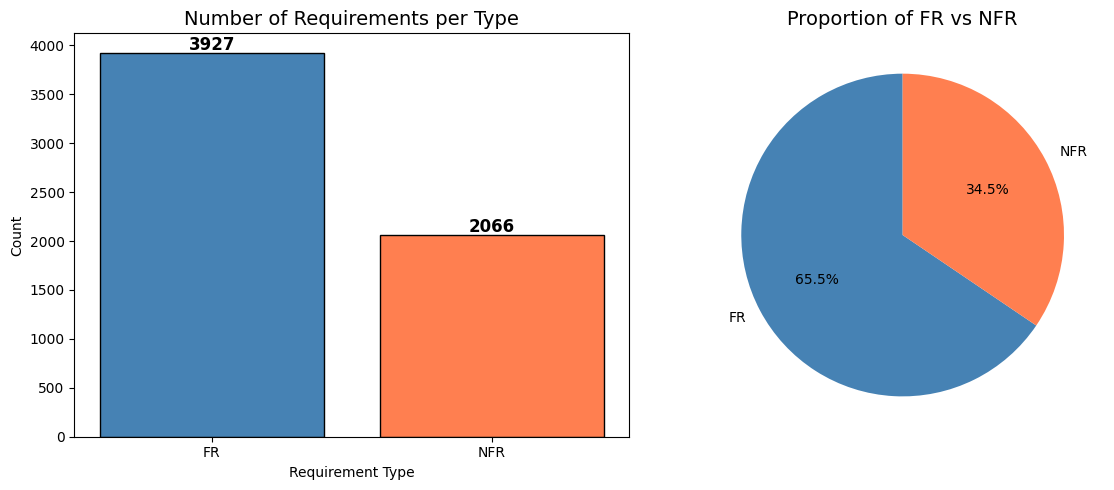


Insight 1: The dataset is imbalanced — FR requirements (65%) outnumber NFR (35%).


In [11]:
# Count how many requirements belong to each category
type_counts = dataset['Type'].value_counts()

print('Class distribution:')
print(type_counts)
print(f'\nFR percentage:  {type_counts["FR"] / len(dataset) * 100:.1f}%')
print(f'NFR percentage: {type_counts["NFR"] / len(dataset) * 100:.1f}%')

# Side-by-side bar chart and pie chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(type_counts.index, type_counts.values, color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('Number of Requirements per Type', fontsize=14)
axes[0].set_xlabel('Requirement Type')
axes[0].set_ylabel('Count')
for i, count in enumerate(type_counts.values):
    axes[0].text(i, count + 30, str(count), ha='center', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(
    type_counts.values,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=['steelblue', 'coral'],
    startangle=90
)
axes[1].set_title('Proportion of FR vs NFR', fontsize=14)

plt.tight_layout()
plt.savefig(f'{drive_folder}/chart_class_distribution.png', dpi=150)
plt.show()
print('\nInsight 1: The dataset is imbalanced — FR requirements (65%) outnumber NFR (35%).')

### Insight 2: Requirement Text Length Distribution

Word count statistics by requirement type:
       count   mean   std  min   25%   50%   75%   max
Type                                                  
FR    3927.0  14.76  5.45  2.0  11.0  14.0  17.0  45.0
NFR   2066.0  14.73  5.21  4.0  11.0  14.0  18.0  58.0


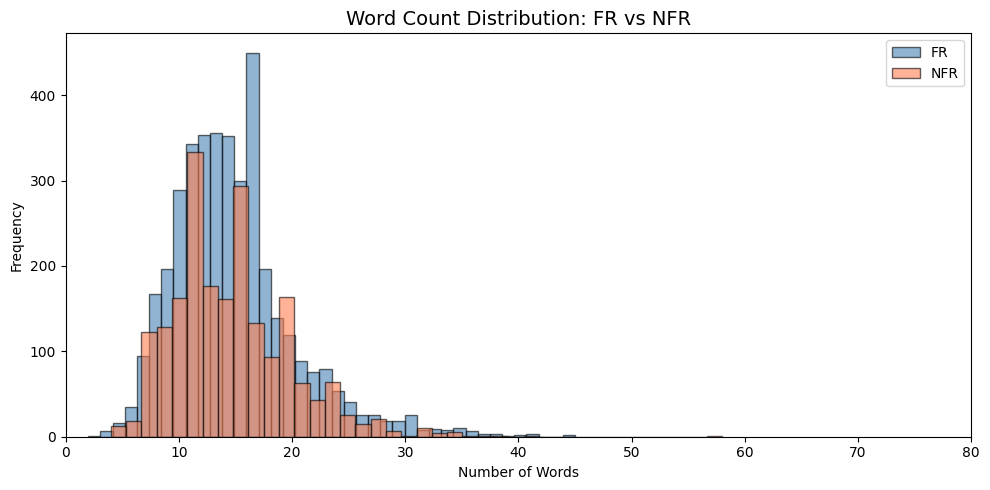


Insight 2: NFR requirements tend to be slightly longer on average than FR requirements.


In [12]:
# Calculate the number of words in each requirement
dataset['Word Count'] = dataset['Requirement Text'].apply(lambda text: len(text.split()))

# Descriptive statistics grouped by type
print('Word count statistics by requirement type:')
print(dataset.groupby('Type')['Word Count'].describe().round(2))

# Overlapping histogram: FR vs NFR word count
fig, ax = plt.subplots(figsize=(10, 5))

fr_word_counts  = dataset[dataset['Type'] == 'FR']['Word Count']
nfr_word_counts = dataset[dataset['Type'] == 'NFR']['Word Count']

ax.hist(fr_word_counts,  bins=40, alpha=0.6, color='steelblue', label='FR',  edgecolor='black')
ax.hist(nfr_word_counts, bins=40, alpha=0.6, color='coral',     label='NFR', edgecolor='black')

ax.set_title('Word Count Distribution: FR vs NFR', fontsize=14)
ax.set_xlabel('Number of Words')
ax.set_ylabel('Frequency')
ax.legend()
ax.set_xlim(0, 80)

plt.tight_layout()
plt.savefig(f'{drive_folder}/chart_word_count_distribution.png', dpi=150)
plt.show()
print('\nInsight 2: NFR requirements tend to be slightly longer on average than FR requirements.')

### Insight 3: Most Frequent Words in FR vs NFR

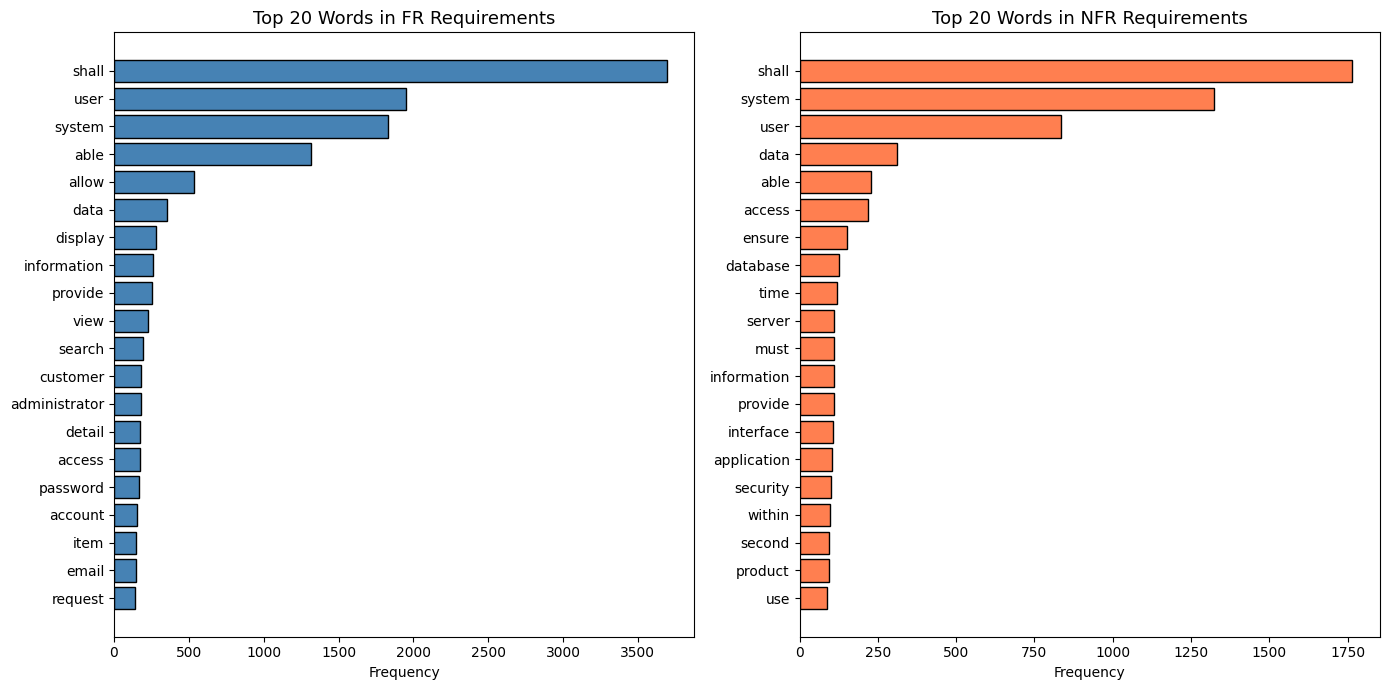


Insight 3: FR requirements use action words like "shall", "user", "system", "display".
NFR requirements use quality-related words like "system", "shall", "time", "performance".


In [13]:
def get_top_words(dataframe, label, top_n=20):
    """Returns a DataFrame of the top N most common words for a given requirement type."""
    # Combine all cleaned text for that label into one big string
    all_text = ' '.join(dataframe[dataframe['Type'] == label]['Cleaned Text'])
    # Count each word
    word_counts = Counter(all_text.split())
    # Return as a DataFrame sorted by frequency
    return pd.DataFrame(word_counts.most_common(top_n), columns=['Word', 'Count'])


top_fr_words  = get_top_words(dataset, 'FR',  top_n=20)
top_nfr_words = get_top_words(dataset, 'NFR', top_n=20)

# Side-by-side horizontal bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].barh(top_fr_words['Word'],  top_fr_words['Count'],  color='steelblue', edgecolor='black')
axes[0].set_title('Top 20 Words in FR Requirements', fontsize=13)
axes[0].set_xlabel('Frequency')
axes[0].invert_yaxis()  # Most frequent word at the top

axes[1].barh(top_nfr_words['Word'], top_nfr_words['Count'], color='coral',     edgecolor='black')
axes[1].set_title('Top 20 Words in NFR Requirements', fontsize=13)
axes[1].set_xlabel('Frequency')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f'{drive_folder}/chart_top_words.png', dpi=150)
plt.show()
print('\nInsight 3: FR requirements use action words like "shall", "user", "system", "display".\n'
      'NFR requirements use quality-related words like "system", "shall", "time", "performance".')

### Insight 4: Word Count Spread — Box Plot

/tmp/ipykernel_2823/888303355.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


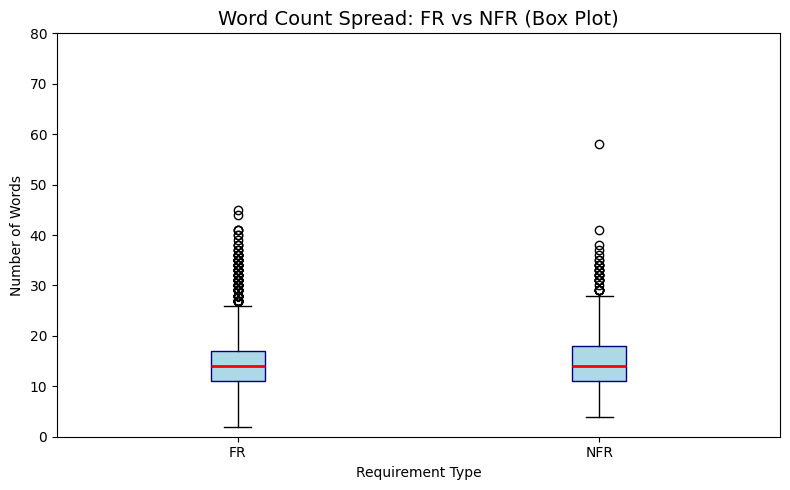


Insight 4: NFR requirements have a wider spread in length compared to FR requirements.


In [14]:
# Box plot shows the median and spread of word counts per category
fig, ax = plt.subplots(figsize=(8, 5))

fr_data  = dataset[dataset['Type'] == 'FR']['Word Count']
nfr_data = dataset[dataset['Type'] == 'NFR']['Word Count']

ax.boxplot(
    [fr_data, nfr_data],
    labels=['FR', 'NFR'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='navy'),
    medianprops=dict(color='red', linewidth=2)
)

ax.set_title('Word Count Spread: FR vs NFR (Box Plot)', fontsize=14)
ax.set_xlabel('Requirement Type')
ax.set_ylabel('Number of Words')
ax.set_ylim(0, 80)

plt.tight_layout()
plt.savefig(f'{drive_folder}/chart_boxplot_word_count.png', dpi=150)
plt.show()
print('\nInsight 4: NFR requirements have a wider spread in length compared to FR requirements.')

### Descriptive Statistics Summary

In [15]:
print('=== Overall Word Count Statistics ===')
print(dataset['Word Count'].describe().round(2))

print('\n=== Word Count Statistics by Type ===')
print(dataset.groupby('Type')['Word Count'].describe().round(2))

=== Overall Word Count Statistics ===
count    5993.00
mean       14.75
std         5.37
min         2.00
25%        11.00
50%        14.00
75%        17.00
max        58.00
Name: Word Count, dtype: float64

=== Word Count Statistics by Type ===
       count   mean   std  min   25%   50%   75%   max
Type                                                  
FR    3927.0  14.76  5.45  2.0  11.0  14.0  17.0  45.0
NFR   2066.0  14.73  5.21  4.0  11.0  14.0  18.0  58.0


In [16]:
# Separate the features (text) and labels (FR/NFR)
text_features      = dataset['Cleaned Text']  # Input
requirement_labels = dataset['Type']           # Output

# Split into training set (80%) and testing set (20%)
# random_state=42 makes the split reproducible — same split every time you run
# stratify keeps the FR/NFR ratio the same in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    text_features,
    requirement_labels,
    test_size=0.2,
    random_state=42,
    stratify=requirement_labels
)

print(f'Training samples: {len(X_train)}')
print(f'Testing samples:  {len(X_test)}')

Training samples: 4794
Testing samples:  1199


In [17]:
# Create the TF-IDF vectorizer
# max_features=5000 : only keep the 5000 most important words
# ngram_range=(1, 2): consider both single words AND two-word pairs (bigrams)
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Fit on training data and transform it to a numeric matrix
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Only transform the test data — do NOT fit again (avoids data leakage)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f'TF-IDF training matrix shape: {X_train_tfidf.shape}')
print(f'TF-IDF testing matrix shape:  {X_test_tfidf.shape}')

TF-IDF training matrix shape: (4794, 5000)
TF-IDF testing matrix shape:  (1199, 5000)


In [18]:
# Create the Logistic Regression classifier
# max_iter=1000: allow enough iterations for the model to fully converge
classifier = LogisticRegression(max_iter=1000, random_state=42)

# Train the model using the training data
classifier.fit(X_train_tfidf, y_train)

print('Model trained successfully!')

Model trained successfully!


In [19]:
# Use the trained model to predict labels on the unseen test data
y_predictions = classifier.predict(X_test_tfidf)

# Overall accuracy
accuracy = accuracy_score(y_test, y_predictions)
print(f'Model Accuracy: {accuracy * 100:.2f}%')

# Detailed report: precision, recall, and F1-score for each class
print('\nClassification Report:')
print(classification_report(y_test, y_predictions))

Model Accuracy: 86.32%

Classification Report:
              precision    recall  f1-score   support

          FR       0.87      0.94      0.90       786
         NFR       0.86      0.72      0.78       413

    accuracy                           0.86      1199
   macro avg       0.86      0.83      0.84      1199
weighted avg       0.86      0.86      0.86      1199



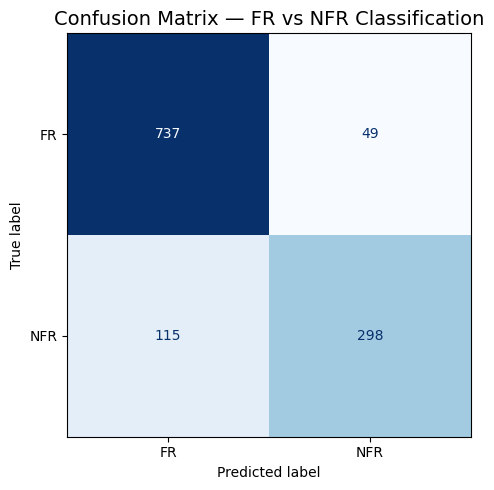

In [20]:
# Confusion matrix: rows = actual, columns = predicted
# Shows how many predictions were correct and where errors occurred
conf_matrix = confusion_matrix(y_test, y_predictions, labels=['FR', 'NFR'])

fig, ax = plt.subplots(figsize=(7, 5))
display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['FR', 'NFR'])
display.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title('Confusion Matrix — FR vs NFR Classification', fontsize=14)
plt.tight_layout()
plt.savefig(f'{drive_folder}/chart_confusion_matrix.png', dpi=150)
plt.show()

### Heatmap of Most Important Words (FR vs NFR)

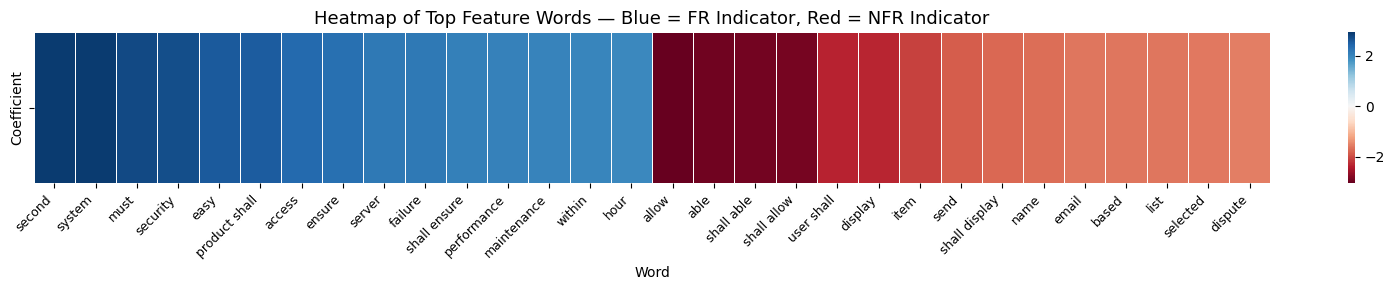

In [21]:
# Get the vocabulary (feature names) from the fitted TF-IDF vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()

# The model's coefficients tell us which words push toward FR vs NFR
# Positive coefficient = more likely FR; Negative = more likely NFR
coefficients = classifier.coef_[0]

word_importance = pd.DataFrame({
    'Word':        feature_names,
    'Coefficient': coefficients
})

# Pick the top 15 FR-leaning and top 15 NFR-leaning words
top_fr_indicator_words  = word_importance.nlargest(15,  'Coefficient')
top_nfr_indicator_words = word_importance.nsmallest(15, 'Coefficient')

heatmap_words = pd.concat([top_fr_indicator_words, top_nfr_indicator_words])
heatmap_data  = heatmap_words.set_index('Word')[['Coefficient']].T

fig, ax = plt.subplots(figsize=(16, 3))
sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap='RdBu',
    center=0,
    annot=False,
    linewidths=0.5
)
ax.set_title('Heatmap of Top Feature Words — Blue = FR Indicator, Red = NFR Indicator', fontsize=13)
ax.set_ylabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig(f'{drive_folder}/chart_feature_heatmap.png', dpi=150)
plt.show()

In [ ]:
def predict_requirement_type(requirement_text, vectorizer, model):
    cleaned    = clean_text(requirement_text)
    vectorized = vectorizer.transform([cleaned])
    label      = model.predict(vectorized)[0]
    confidence = max(model.predict_proba(vectorized)[0]) * 100
    return label, confidence


# Test with a handful of example requirements
test_examples = [
    'The user shall be able to log in using a username and password.',
    'The system shall respond to all requests within 2 seconds.',
    'The application shall allow users to upload profile pictures.',
    'The system shall be available 99.9% of the time.',
    'The admin shall be able to delete user accounts.',
]

print(f'{"Requirement":<60} {"Predicted":<12} {"Confidence"}')
print('-' * 88)
for example in test_examples:
    label, confidence = predict_requirement_type(example, tfidf_vectorizer, classifier)
    print(f'{example[:58]:<60} {label:<12} {confidence:.1f}%')

Requirement                                                  Predicted    Confidence
----------------------------------------------------------------------------------------
The user shall be able to log in using a username and pass   FR           91.3%
The system shall respond to all requests within 2 seconds.   NFR          90.6%
The application shall allow users to upload profile pictur   FR           93.4%
The system shall be available 99.9% of the time.             NFR          72.8%
The admin shall be able to delete user accounts.             FR           93.0%


In [ ]:
# Save the TF-IDF vectorizer (stores the vocabulary learned from training data)
joblib.dump(tfidf_vectorizer, vectorizer_save_path)

# Save the trained Logistic Regression classifier
joblib.dump(classifier, classifier_save_path)

print('Model files saved to Google Drive successfully!')
